In [ ]:
#imports and package setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix
from pytorch_tabnet.tab_model import TabNetClassifier
import torch


In [ ]:
# synthetic data generation 
np.random.seed(42)
n_patients = 5000
seqn = np.arange(100000, 100000 + n_patients)

demo = pd.DataFrame({
    'SEQN': seqn,
    'AGE': np.random.normal(55, 15, n_patients).clip(18, 85).astype(int),
    'SEX': np.random.choice([1, 2], n_patients),
    'ETHNICITY': np.random.choice([1,2,3,4,6,7], n_patients)
})

biol = pd.DataFrame({'SEQN': seqn, 'HBA1C': np.random.normal(6.5, 2.0, n_patients).clip(4.0, 15.0)})
bp   = pd.DataFrame({'SEQN': seqn, 'SBP': np.random.normal(130, 20, n_patients).clip(90, 200)})
bmx  = pd.DataFrame({'SEQN': seqn, 'BMI': np.random.normal(28, 6, n_patients).clip(15, 60)})
alb  = pd.DataFrame({'SEQN': seqn, 'UACR': np.random.lognormal(2,1.5,n_patients).clip(0.1,1000)})
mort = pd.DataFrame({'SEQN': seqn, 'DIED': np.random.choice([0,1],n_patients,p=[0.85,0.15]), 'FOLLOW_UP_MONTHS': np.random.exponential(120,n_patients).clip(1,240).astype(int)})

diab = pd.DataFrame({'SEQN': seqn, 'DIQ010': np.random.choice([1,2,3,9],n_patients,p=[0.15,0.75,0.05,0.05])})

In [ ]:
# merging and filtering

df = demo.merge(biol, on='SEQN').merge(bp,on='SEQN').merge(bmx,on='SEQN').merge(alb,on='SEQN').merge(mort,on='SEQN').merge(diab,on='SEQN')
df = df[df['DIQ010']==1].copy()

# Feature engineering
df['HBA1C_MMOL'] = (df['HBA1C'] - 2.15) * 10.929
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[17, 40, 55, 70, 100], labels=['<40','40-55','55-70','70+'])
df['LOG_UACR'] = np.log1p(df['UACR'])
df['FOLLOW_UP_YEARS'] = df['FOLLOW_UP_MONTHS'] / 12

# Apply final filtering before modeling
df = df[(df['HBA1C_MMOL'].between(20,195)) & (df['BMI'].between(14,70)) & (df['SBP'].between(60,280)) & (df['AGE']>=18)]
df = df.dropna(subset=['AGE','SEX','BMI','SBP','HBA1C_MMOL','LOG_UACR','DIED'])

print('Final sample size after filtering:', len(df))

Final sample size after filtering: 733



--- Basic descriptive stats ---
              AGE         SEX         BMI         SBP  HBA1C_MMOL    LOG_UACR  \
count  733.000000  733.000000  733.000000  733.000000  733.000000  733.000000   
mean    53.511596    1.484311   28.305606  129.258134   48.104325    2.218315   
std     14.264823    0.500095    5.985787   19.910086   19.770445    1.231439   
min     18.000000    1.000000   15.000000   90.000000   20.218650    0.095310   
25%     44.000000    1.000000   24.196576  115.193178   32.581932    1.289262   
50%     54.000000    1.000000   28.263429  128.846586   46.713164    2.071850   
75%     63.000000    2.000000   32.301729  143.651983   60.955476    2.996835   
max     85.000000    2.000000   46.974504  185.547217  108.906520    6.908755   

       FOLLOW_UP_YEARS        DIED  
count       733.000000  733.000000  
mean          8.851069    0.154161  
std           6.781655    0.361350  
min           0.083333    0.000000  
25%           2.916667    0.000000  
50%           7

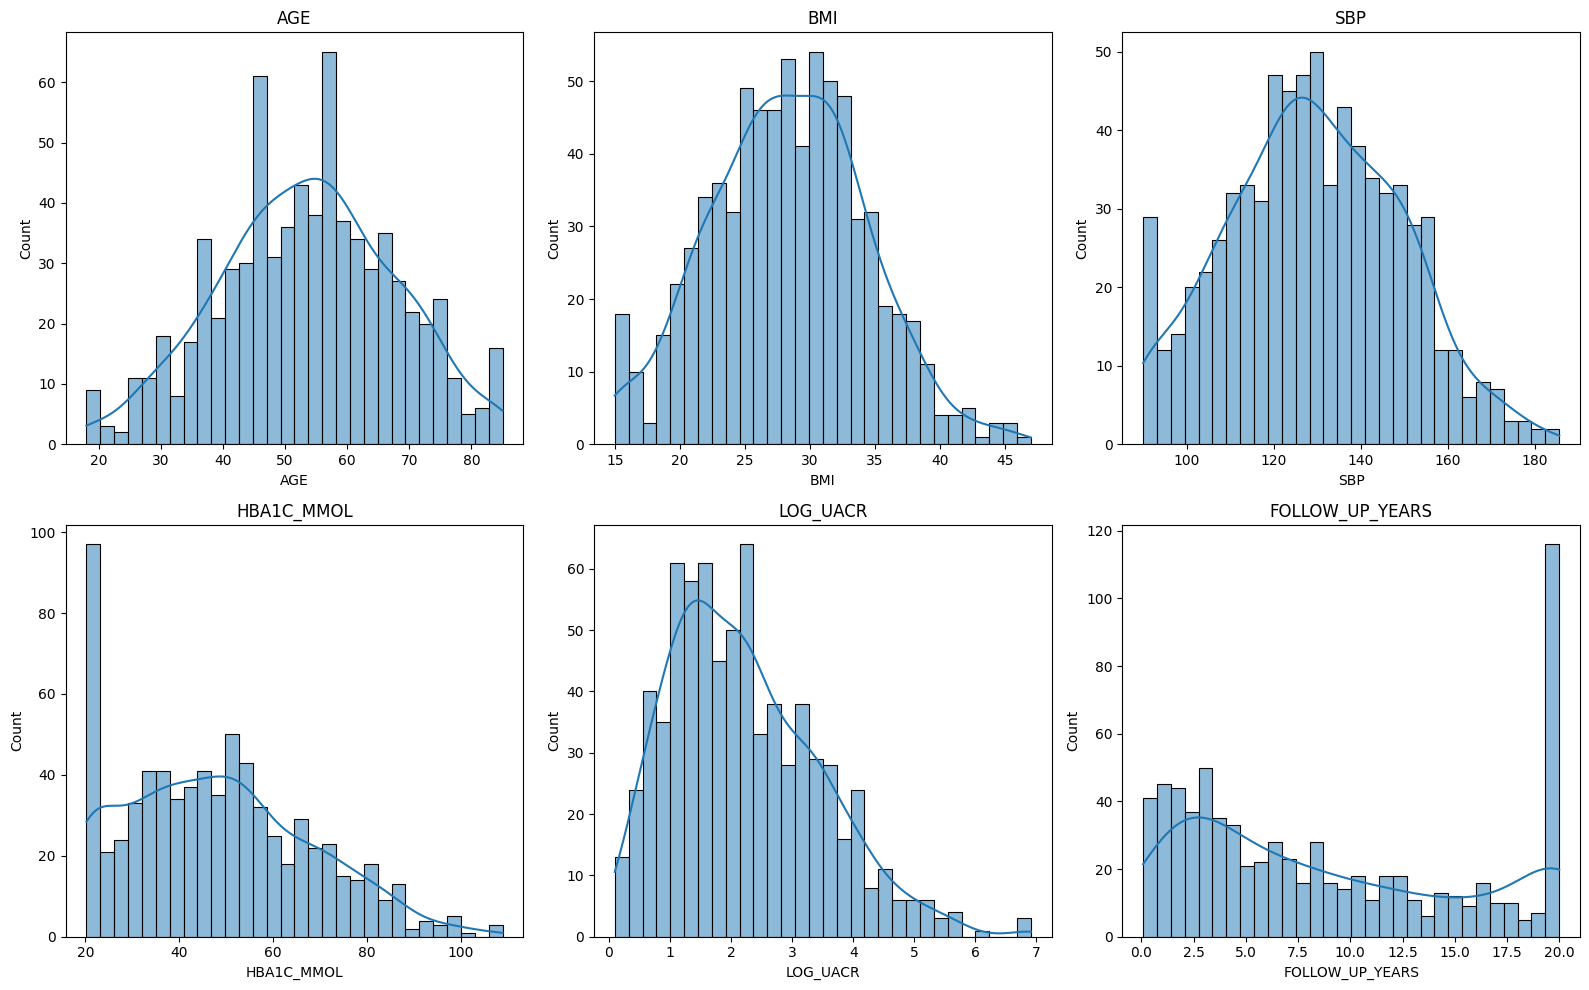

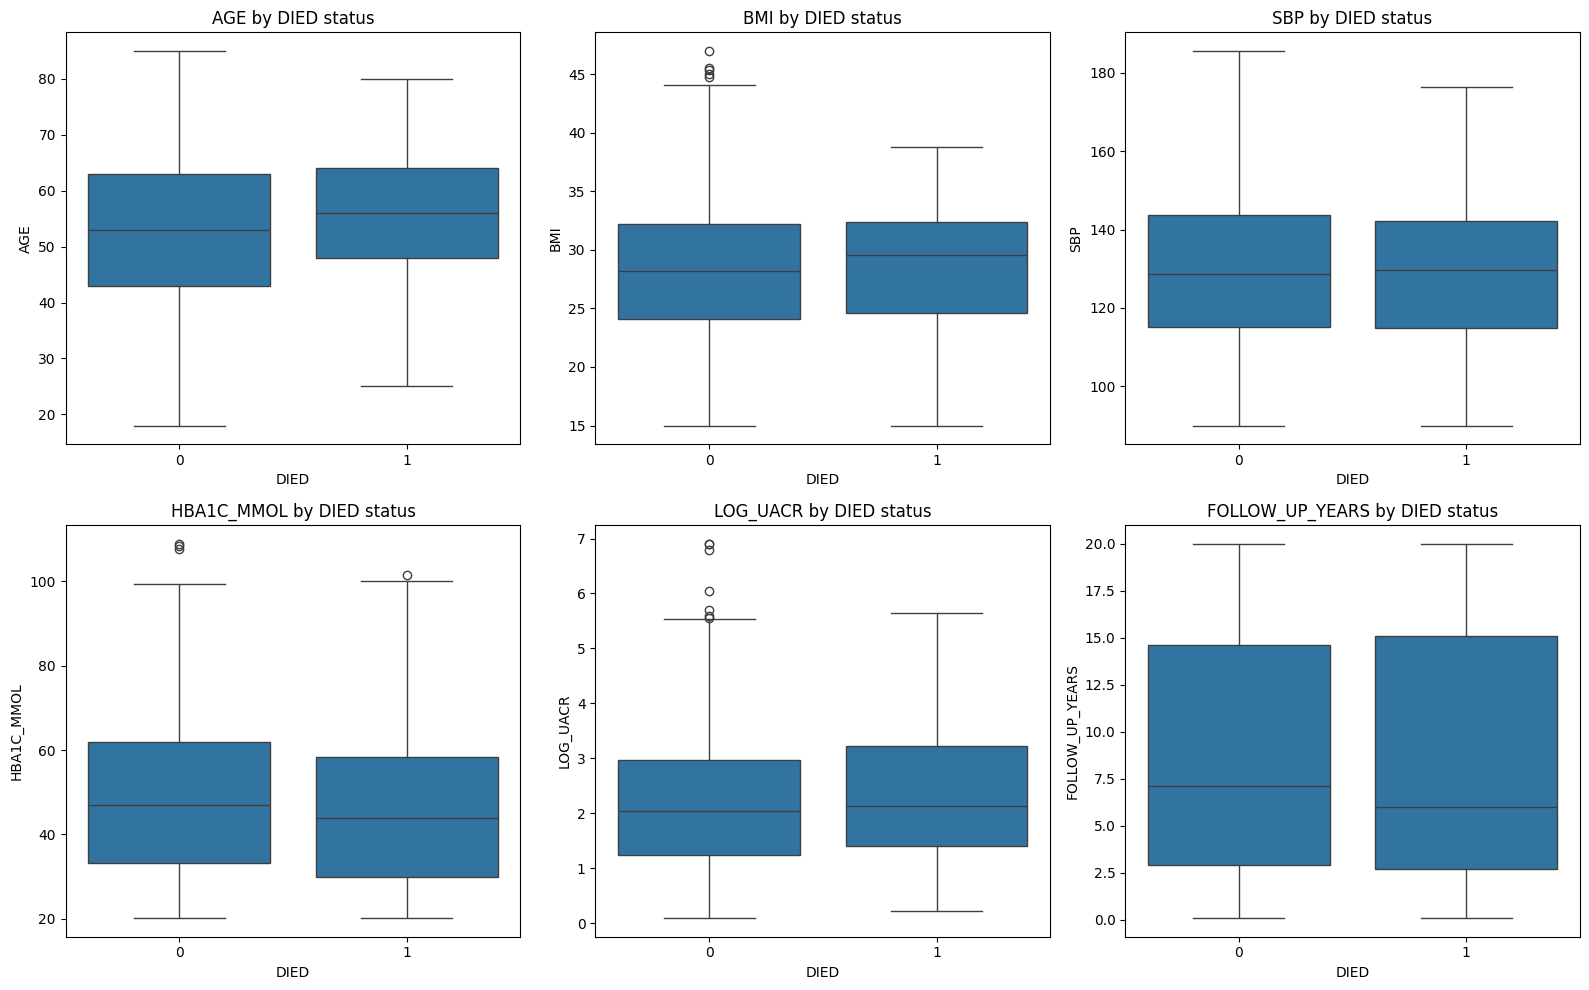

In [ ]:
# EDA and visualisation
print('\n--- Basic descriptive stats ---')
print(df[['AGE','SEX','BMI','SBP','HBA1C_MMOL','LOG_UACR','FOLLOW_UP_YEARS','DIED']].describe())

print('\n--- Class balance ---')
print(df['DIED'].value_counts(normalize=True))

corr = df[['AGE','BMI','SBP','HBA1C_MMOL','LOG_UACR','DIED']].corr()
print('\n--- Correlation matrix ---\n', corr)

fig, axes = plt.subplots(2,3,figsize=(16,10))
vars_to_plot=['AGE','BMI','SBP','HBA1C_MMOL','LOG_UACR','FOLLOW_UP_YEARS']
for ax,var in zip(axes.flatten(),vars_to_plot):
    sns.histplot(df[var], ax=ax, kde=True, bins=30)
    ax.set_title(var)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2,3,figsize=(16,10))
for ax,var in zip(axes.flatten(), ['AGE','BMI','SBP','HBA1C_MMOL','LOG_UACR','FOLLOW_UP_YEARS']):
    sns.boxplot(x='DIED', y=var, data=df, ax=ax)
    ax.set_title(f'{var} by DIED status')
plt.tight_layout(); plt.show()

In [ ]:
# prepare training / test data
features = ['AGE','SEX','BMI','SBP','HBA1C_MMOL','LOG_UACR']
X = df[features].values
y = df['DIED'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (513, 6) Test: (220, 6)


In [ ]:
#train TabNet model
clf = TabNetClassifier(seed=42, verbose=0)
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_name=['train','valid'],
    eval_metric=['auc'],
    max_epochs=80,
    patience=10,
    batch_size=256,
    virtual_batch_size=64
)



Early stopping occurred at epoch 17 with best_epoch = 7 and best_valid_auc = 0.53321


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
#model evaluation

y_pred_proba = clf.predict_proba(X_test)[:,1]
y_pred = clf.predict(X_test)
print('\n--- TabNet test set performance ---')
print('Accuracy:', accuracy_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba))
print('F1:', f1_score(y_test, y_pred))
print('\nClassification report:\n', classification_report(y_test, y_pred))
print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))



--- TabNet test set performance ---
Accuracy: 0.8454545454545455
ROC-AUC: 0.5332068311195446
F1: 0.0

Classification report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       186
           1       0.00      0.00      0.00        34

    accuracy                           0.85       220
   macro avg       0.42      0.50      0.46       220
weighted avg       0.71      0.85      0.77       220

Confusion matrix:
 [[186   0]
 [ 34   0]]


/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/s223901316/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

In [9]:
# Cell 8: interpretation and feature importance
print('\n--- Data summary and interpretation ---')
print('Observations: features are synthetic NHANES-like values with realistic clinical ranges.')
print('Target event (DIED) is imbalanced (~15%); TabNet may predict majority class if not adjusted.')

feature_importances = clf.feature_importances_
print('\nTabNet feature importances:')
for f,imp in zip(features, feature_importances):
    print(f'{f}: {imp:.4f}')



--- Data summary and interpretation ---
Observations: features are synthetic NHANES-like values with realistic clinical ranges.
Target event (DIED) is imbalanced (~15%); TabNet may predict majority class if not adjusted.

TabNet feature importances:
AGE: 0.1174
SEX: 0.0821
BMI: 0.1745
SBP: 0.1817
HBA1C_MMOL: 0.2401
LOG_UACR: 0.2042
